In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_excel("dataset.xlsx")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (689, 58)

Columns:
['Timestamp', 'Email address', 'Age', 'Gender', 'College Name', 'Name of the Course', 'Family Size', 'Monthly Family Income', 'Which of the following best describes your living arrangement?', 'Religion', 'Caste', 'Do you consider yourself ', 'How many friends do you have?', 'What are your hobbies?', 'Have you used any of the below substances in the past ? Please select all that apply', 'What is your sexual orientation?', "What is your father's profession?", "What is your mother's profession?", 'How many siblings do you have?', 'What is your spiritual orientation or belief system?', '  How many parent/guardian figures do you currently live with?  ', 'Are you currently in a relationship?', 'Have you experienced a relationship breakup in the past?', 'Do you feel pressure from your Society, parents or guardians to meet certain expectations?', 'Have you ever experienced social exclusion or felt left out in social situations?', 'Have you ever experienced peer press

In [4]:
asiq_cols = [
    col
    for col in df.columns
    if "This thought was in my mind"
    in col
]

print("Number of ASIQ Questions:", len(asiq_cols))

for col in asiq_cols[:3]:

    print("\nCOLUMN:")
    print(col)

    print(df[col].value_counts(dropna=False).head(15))

    print("-"*60)

Number of ASIQ Questions: 25

COLUMN:
This thought was in my mind [I thought it would be better if I was not alive]
This thought was in my mind [I thought it would be better if I was not alive]
I never had this thought                                                         450
I had this thought before but not in the past month                               82
Couple of times a month                                                           36
Almost every day                                                                  35
About once a month                                                                30
Couple of times a week                                                            25
About once a week                                                                 23
Almost every day, I had this thought before but not in the past month              2
I had this thought before but not in the past month, I never had this thought      2
About once a week, I never had this thoug

In [5]:
def convert_asiq_response(response):

    if pd.isna(response):
        return 0

    response = str(response).lower()

    if "almost every day" in response:
        return 6

    elif "couple of times a week" in response:
        return 5

    elif "about once a week" in response:
        return 4

    elif "couple of times a month" in response:
        return 3

    elif "about once a month" in response:
        return 2

    elif "before but not in the past month" in response:
        return 1

    elif "never had this thought" in response:
        return 0

    return 0

In [6]:
for col in asiq_cols:
    df[col] = df[col].apply(convert_asiq_response)

In [7]:
df["ASIQ_Total_Score"] = df[asiq_cols].sum(axis=1)

print(df["ASIQ_Total_Score"].describe())

count    689.000000
mean      17.253991
std       32.607393
min        0.000000
25%        0.000000
50%        1.000000
75%       15.000000
max      150.000000
Name: ASIQ_Total_Score, dtype: float64


ASIQ_Total_Score
0      310
1       38
2       25
6       22
4       19
3       18
9       17
5       16
75      14
7        9
8        9
11       9
10       8
16       7
12       6
21       6
17       6
15       6
25       6
100      5
Name: count, dtype: int64


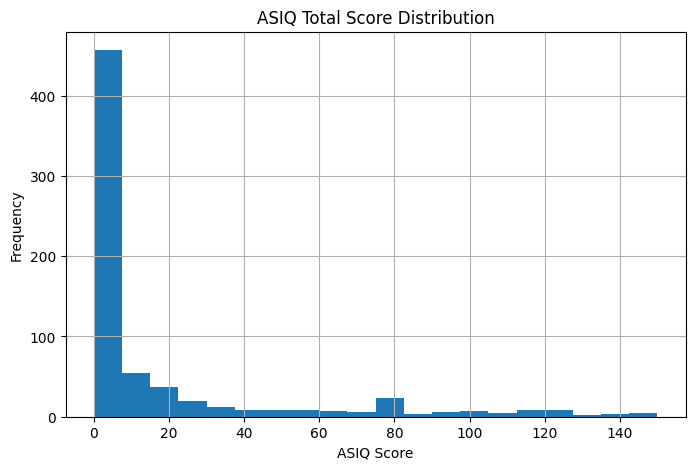

In [8]:
print(df["ASIQ_Total_Score"].value_counts().head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["ASIQ_Total_Score"].hist(bins=20)

plt.title("ASIQ Total Score Distribution")

plt.xlabel("ASIQ Score")

plt.ylabel("Frequency")

plt.show()

In [9]:
print(df["ASIQ_Total_Score"].describe())

count    689.000000
mean      17.253991
std       32.607393
min        0.000000
25%        0.000000
50%        1.000000
75%       15.000000
max      150.000000
Name: ASIQ_Total_Score, dtype: float64


In [10]:
friend_map = {
    "Greater than 20":0,
    "10-20":1,
    "5-10":2,
    "Less than 5":3
}

df["Friend_Risk"] = (
    df["How many friends do you have?"]
    .map(friend_map)
)

yes_no_map = {
    "No":0,
    "Maybe":1,
    "Yes":2
}

df["Social_Exclusion"] = (
    df["Have you ever experienced social exclusion or felt left out in social situations?"]
    .map(yes_no_map)
)

df["Social_Isolation_Score"] = (
    df["Friend_Risk"]
    +
    df["Social_Exclusion"]
)

print(
    df["Social_Isolation_Score"]
    .describe()
)

count    689.000000
mean       2.107402
std        1.652189
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: Social_Isolation_Score, dtype: float64


In [11]:
relationship_map = {
    "No":0,
    "Maybe":1,
    "Yes":2
}

df["Current_Relationship"] = (
    df["Are you currently in a relationship?"]
    .map(relationship_map)
)

df["Breakup_Score"] = (
    df["Have you experienced a relationship breakup in the past?"]
    .map(relationship_map)
)

df["Relationship_Distress_Index"] = (
    (2 - df["Current_Relationship"])
    +
    df["Breakup_Score"]
)

print(
    df["Relationship_Distress_Index"]
    .describe()
)

count    689.000000
mean       2.097242
std        0.982762
min        0.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: Relationship_Distress_Index, dtype: float64


In [12]:
for col in df.columns:
    if "support" in col.lower():
        print(col)

If you feel mentally depressed, who do you typically contact for support or help?
At times of personal crisis, who do you typically talk to for support or help?
Who provided you with the most support during difficult times / crisis?
Have you ever contacted a counselor for support or guidance?


In [13]:
import numpy as np

support_col = "Who provided you with the most support during difficult times / crisis?"

yes_no_map = {
    "No":0,
    "Maybe":1,
    "Yes":2
}

df["Family_Support"] = np.where(
    df[support_col]
    .astype(str)
    .str.contains(
        "family",
        case=False,
        na=False
    ),
    2,
    0
)

df["Friend_Support"] = np.where(
    df[support_col]
    .astype(str)
    .str.contains(
        "friend",
        case=False,
        na=False
    ),
    2,
    0
)

df["Counselor_Contact"] = (
    df[
        "Have you ever contacted a counselor for support or guidance?"
    ]
    .astype(str)
    .str.strip()
    .map(yes_no_map)
)

df["Counselor_Contact"] = df["Counselor_Contact"].fillna(0)

df["Protective_Factor_Score"] = (
    df["Family_Support"]
    +
    df["Friend_Support"]
    +
    df["Counselor_Contact"]
)

print(df["Protective_Factor_Score"].describe())

count    689.000000
mean       2.139332
std        0.958912
min        0.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: Protective_Factor_Score, dtype: float64


In [14]:
print(df["Protective_Factor_Score"].head())

0    2
1    4
2    2
3    2
4    2
Name: Protective_Factor_Score, dtype: int64


In [15]:
df["Crisis_Risk_Score"] = (
    df["ASIQ_Total_Score"]
    +
    df["Social_Isolation_Score"]
    +
    df["Relationship_Distress_Index"]
    -
    df["Protective_Factor_Score"]
)

print(df["Crisis_Risk_Score"].describe())

count    689.000000
mean      19.319303
std       32.888062
min       -3.000000
25%        1.000000
50%        5.000000
75%       18.000000
max      156.000000
Name: Crisis_Risk_Score, dtype: float64


In [16]:
print(df["Protective_Factor_Score"].describe())

print(df["Crisis_Risk_Score"].describe())

count    689.000000
mean       2.139332
std        0.958912
min        0.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: Protective_Factor_Score, dtype: float64
count    689.000000
mean      19.319303
std       32.888062
min       -3.000000
25%        1.000000
50%        5.000000
75%       18.000000
max      156.000000
Name: Crisis_Risk_Score, dtype: float64


In [17]:
df["Risk_Level"] = pd.qcut(
    df["Crisis_Risk_Score"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    duplicates="drop"
)

print(df["Risk_Level"].value_counts())

Risk_Level
Low       243
Medium    227
High      219
Name: count, dtype: int64


In [18]:
def cronbach_alpha(df_items):

    items = df_items.to_numpy()

    item_variances = items.var(
        axis=0,
        ddof=1
    )

    total_score = items.sum(axis=1)

    total_variance = total_score.var(
        ddof=1
    )

    n_items = items.shape[1]

    alpha = (
        n_items / (n_items - 1)
    ) * (
        1 -
        item_variances.sum() /
        total_variance
    )

    return alpha

alpha = cronbach_alpha(
    df[asiq_cols]
)

print(
    "Cronbach Alpha:",
    round(alpha,4)
)

Cronbach Alpha: 0.9859


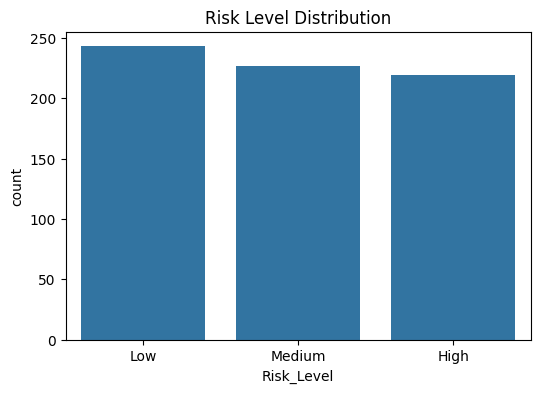

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="Risk_Level",
    data=df
)

plt.title("Risk Level Distribution")

plt.show()

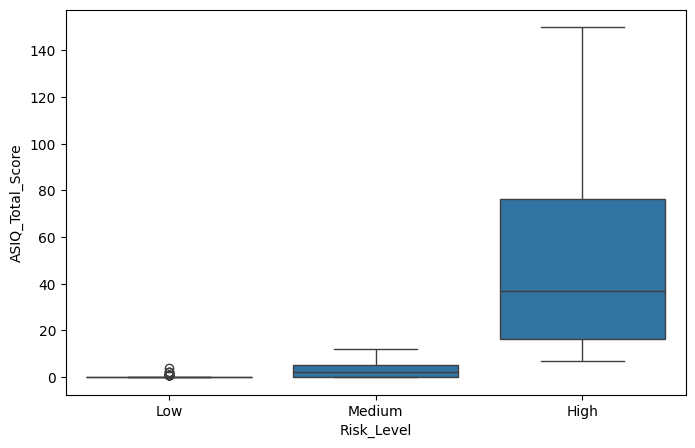

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Risk_Level",
    y="ASIQ_Total_Score",
    data=df
)

plt.show()

In [21]:
from scipy.stats import chi2_contingency

chi_results = []

test_cols = [
    "Gender",
    "Have you ever experienced peer pressure?",
    "Have you experienced a relationship breakup in the past?",
    "Are you currently in a relationship?",
    "Do you feel pressure from your Society, parents or guardians to meet certain expectations?",
    "How many friends do you have?"
]

for col in test_cols:

    contingency_table = pd.crosstab(
        df[col],
        df["Risk_Level"]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_results.append([
        col,
        round(chi2,4),
        round(p,6)
    ])

chi_df = pd.DataFrame(
    chi_results,
    columns=[
        "Variable",
        "Chi2",
        "p_value"
    ]
)

print(chi_df)

                                            Variable      Chi2   p_value
0                                             Gender    6.4287  0.040182
1           Have you ever experienced peer pressure?   84.6159  0.000000
2  Have you experienced a relationship breakup in...   41.2333  0.000000
3               Are you currently in a relationship?   29.7548  0.000005
4  Do you feel pressure from your Society, parent...   88.1663  0.000000
5                      How many friends do you have?  158.8898  0.000000


                             ASIQ_Total_Score  Social_Isolation_Score  \
ASIQ_Total_Score                     1.000000                0.222857   
Social_Isolation_Score               0.222857                1.000000   
Relationship_Distress_Index         -0.104141                0.036526   
Protective_Factor_Score              0.062505               -0.101202   
Crisis_Risk_Score                    0.997727                0.275234   

                             Relationship_Distress_Index  \
ASIQ_Total_Score                               -0.104141   
Social_Isolation_Score                          0.036526   
Relationship_Distress_Index                     1.000000   
Protective_Factor_Score                         0.053465   
Crisis_Risk_Score                              -0.073094   

                             Protective_Factor_Score  Crisis_Risk_Score  
ASIQ_Total_Score                            0.062505           0.997727  
Social_Isolation_Score                     -0.101202

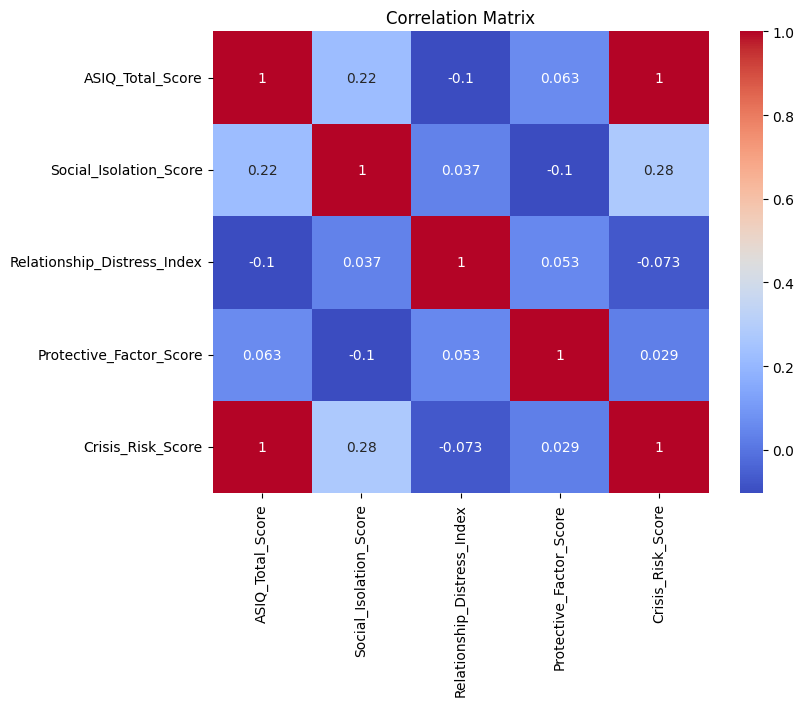

In [22]:
numeric_features = [
    "ASIQ_Total_Score",
    "Social_Isolation_Score",
    "Relationship_Distress_Index",
    "Protective_Factor_Score",
    "Crisis_Risk_Score"
]

corr_matrix = df[numeric_features].corr()

print(corr_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [23]:
print(corr_matrix)

                             ASIQ_Total_Score  Social_Isolation_Score  \
ASIQ_Total_Score                     1.000000                0.222857   
Social_Isolation_Score               0.222857                1.000000   
Relationship_Distress_Index         -0.104141                0.036526   
Protective_Factor_Score              0.062505               -0.101202   
Crisis_Risk_Score                    0.997727                0.275234   

                             Relationship_Distress_Index  \
ASIQ_Total_Score                               -0.104141   
Social_Isolation_Score                          0.036526   
Relationship_Distress_Index                     1.000000   
Protective_Factor_Score                         0.053465   
Crisis_Risk_Score                              -0.073094   

                             Protective_Factor_Score  Crisis_Risk_Score  
ASIQ_Total_Score                            0.062505           0.997727  
Social_Isolation_Score                     -0.101202

In [24]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

label_encoders = {}

for col in df_encoded.columns:

    if df_encoded[col].dtype == object:

        le = LabelEncoder()

        df_encoded[col] = le.fit_transform(
            df_encoded[col].astype(str)
        )

        label_encoders[col] = le

print("Encoding Complete")

Encoding Complete


In [25]:
y = df["Risk_Level"]

X = df_encoded.drop(
    columns=["Risk_Level"]
)

print(X.shape)

(689, 70)


In [26]:
cols_to_drop = []

if "Timestamp" in X.columns:
    cols_to_drop.append("Timestamp")

if "Email address" in X.columns:
    cols_to_drop.append("Email address")

X = X.drop(columns=cols_to_drop)

print(X.shape)

(689, 68)


In [27]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_fs = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_fs.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_fs.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features")
print(importance_df.head(20))

Top 20 Important Features
                                              Feature  Importance
67                                  Crisis_Risk_Score    0.292351
56                                   ASIQ_Total_Score    0.133243
59                             Social_Isolation_Score    0.046515
31  This thought was in my mind [I thought about h...    0.046231
24  This thought was in my mind [I thought it woul...    0.033663
57                                        Friend_Risk    0.031204
33  This thought was in my mind [I thought about h...    0.027676
42  This thought was in my mind [I thought that li...    0.024474
30  This thought was in my mind [I thought that pe...    0.024330
46  This thought was in my mind [I thought that no...    0.023895
41  This thought was in my mind [I thought about h...    0.020084
10                      How many friends do you have?    0.017460
43  This thought was in my mind [I thought that my...    0.015696
34  This thought was in my mind [I thought that ki

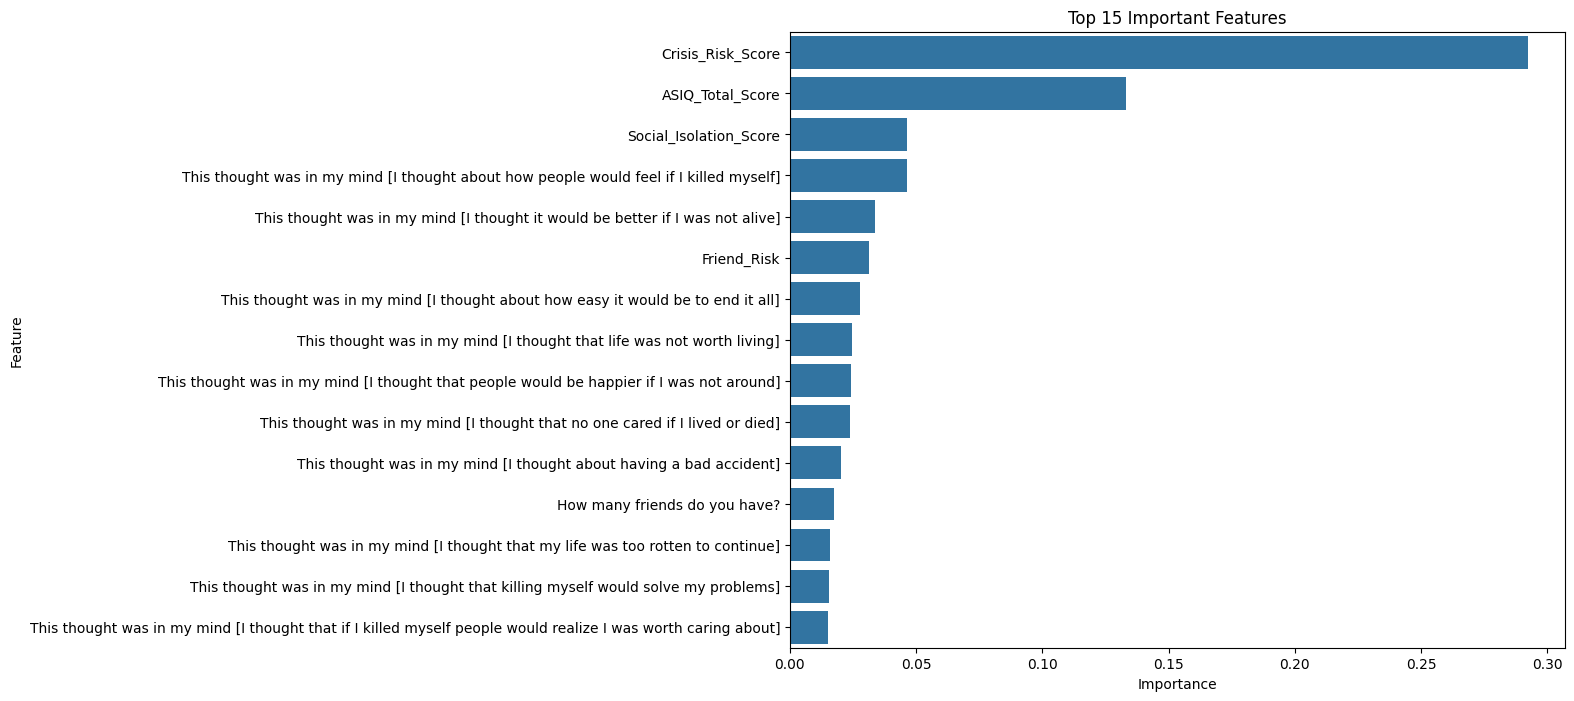

In [28]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

In [29]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(
    score_func=chi2,
    k=20
)

X_selected = selector.fit_transform(
    abs(X),
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['This thought was in my mind [I thought it would be better if I was not alive]', 'This thought was in my mind [I thought about killing myself]', 'This thought was in my mind [I thought that people would be happier if I was not around]', 'This thought was in my mind [I thought about how people would feel if I killed myself]', 'This thought was in my mind [I wished I were dead]', 'This thought was in my mind [I thought about how easy it would be to end it all]', 'This thought was in my mind [I thought that killing myself would solve my problems]', 'This thought was in my mind [I thought that others would be better off if I was dead]', 'This thought was in my mind [I wished that I had never been born]', 'This thought was in my mind [I thought that if I had the chance I would kill myself]', 'This thought was in my mind [I thought about ways people kill themselves]', 'This thought was in my mind [I thought about killing myself, but would not do it]', 'This thought was in

In [30]:
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly Correlated Features:")
print(to_drop)

Highly Correlated Features:
['ASIQ_Total_Score', 'Crisis_Risk_Score']


In [31]:
top_features = (
    importance_df
    .head(20)["Feature"]
    .tolist()
)

print(top_features)

['Crisis_Risk_Score', 'ASIQ_Total_Score', 'Social_Isolation_Score', 'This thought was in my mind [I thought about how people would feel if I killed myself]', 'This thought was in my mind [I thought it would be better if I was not alive]', 'Friend_Risk', 'This thought was in my mind [I thought about how easy it would be to end it all]', 'This thought was in my mind [I thought that life was not worth living]', 'This thought was in my mind [I thought that people would be happier if I was not around]', 'This thought was in my mind [I thought that no one cared if I lived or died]', 'This thought was in my mind [I thought about having a bad accident]', 'How many friends do you have?', 'This thought was in my mind [I thought that my life was too rotten to continue]', 'This thought was in my mind [I thought that killing myself would solve my problems]', 'This thought was in my mind [I thought that if I killed myself people would realize I was worth caring about]', 'This thought was in my mind 

In [32]:
X_final = X[top_features]

print(X_final.shape)

(689, 20)


In [33]:
feature_selection_report = pd.DataFrame({
    "Selected_Features": top_features
})

feature_selection_report.to_csv(
    "selected_features.csv",
    index=False
)

print("Feature selection completed.")

Feature selection completed.


In [34]:
# Final dataset for model training
final_training_dataset = X_final.copy()

# Add target column
final_training_dataset["Risk_Level"] = y

# Save it
final_training_dataset.to_csv(
    "final_training_dataset.csv",
    index=False
)

print("Final training dataset saved successfully!")

Final training dataset saved successfully!


Anomaly detection

In [35]:
# Standardize Features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_final)

print("Feature scaling completed.")

Feature scaling completed.


In [36]:
# using isolation forest
iso = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42
)

iso_labels = iso.fit_predict(X_scaled)

iso_scores = iso.decision_function(X_scaled)

df["IsolationForest_Label"] = np.where(
    iso_labels == -1,
    "Outlier",
    "Normal"
)

df["IsolationForest_Score"] = iso_scores

print("\nIsolation Forest Results")

print(df["IsolationForest_Label"].value_counts())


Isolation Forest Results
IsolationForest_Label
Normal     633
Outlier     56
Name: count, dtype: int64


In [37]:
# Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.08
)

lof_labels = lof.fit_predict(X_scaled)

lof_scores = lof.negative_outlier_factor_

df["LOF_Label"] = np.where(
    lof_labels == -1,
    "Outlier",
    "Normal"
)

df["LOF_Score"] = lof_scores

print("\nLocal Outlier Factor Results")

print(df["LOF_Label"].value_counts())


Local Outlier Factor Results
LOF_Label
Normal     633
Outlier     56
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [38]:
# One-Class SVM
svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.08
)

svm.fit(X_scaled)

svm_labels = svm.predict(X_scaled)

svm_scores = svm.decision_function(X_scaled)

df["OneClassSVM_Label"] = np.where(
    svm_labels == -1,
    "Outlier",
    "Normal"
)

df["OneClassSVM_Score"] = svm_scores

print("\nOne-Class SVM Results")

print(df["OneClassSVM_Label"].value_counts())


One-Class SVM Results
OneClassSVM_Label
Normal     638
Outlier     51
Name: count, dtype: int64


In [39]:
df["Anomaly_Votes"] = (
    (df["IsolationForest_Label"]=="Outlier").astype(int)
    +
    (df["LOF_Label"]=="Outlier").astype(int)
    +
    (df["OneClassSVM_Label"]=="Outlier").astype(int)
)

def anomaly_level(votes):

    if votes == 0:
        return "Normal"

    elif votes == 1:
        return "Moderate Outlier"

    else:
        return "Critical Outlier"

df["Anomaly_Level"] = df["Anomaly_Votes"].apply(anomaly_level)

print("\nFinal Anomaly Levels")

print(df["Anomaly_Level"].value_counts())


Final Anomaly Levels
Anomaly_Level
Normal              556
Moderate Outlier    103
Critical Outlier     30
Name: count, dtype: int64


anomaly visualization

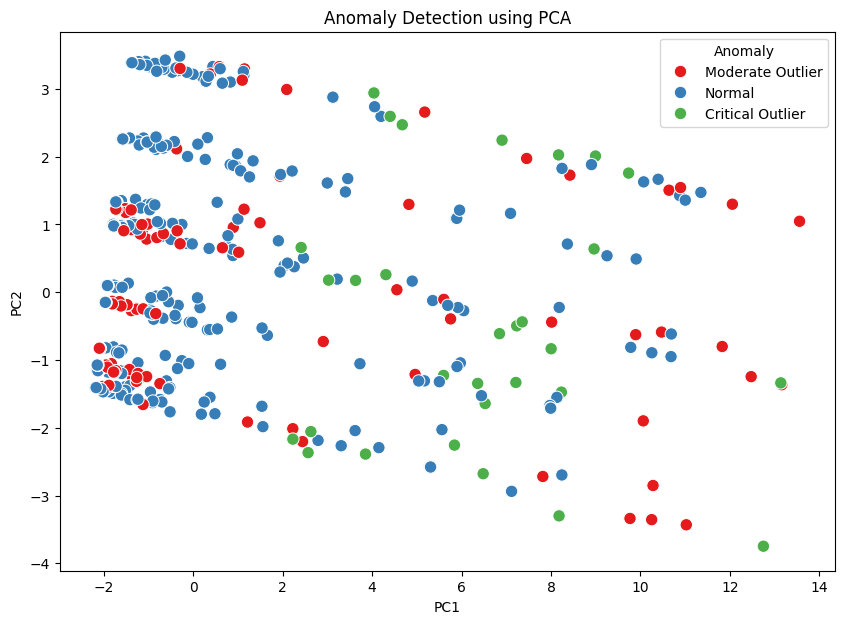

In [40]:
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame()

plot_df["PC1"] = pca_features[:,0]
plot_df["PC2"] = pca_features[:,1]
plot_df["Anomaly"] = df["Anomaly_Level"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette="Set1",
    s=80
)

plt.title("Anomaly Detection using PCA")

plt.show()

In [41]:
df.to_csv(
    "dataset_with_anomalies.csv",
    index=False
)

print("Anomaly dataset saved.")

Anomaly dataset saved.


clustering

In [42]:
#kmeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("KMeans Silhouette Score:", round(score,4))

KMeans Silhouette Score: 0.3404


In [43]:
# Hierarchical Clustering
hier = AgglomerativeClustering(
    n_clusters=4
)

hier_labels = hier.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hier_labels

score = silhouette_score(
    X_scaled,
    hier_labels
)

print("Hierarchical Silhouette:", round(score,4))

Hierarchical Silhouette: 0.3359


In [48]:
# DBSCAN
dbscan = DBSCAN(
    eps=2.5,
    min_samples=8
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

valid = db_labels != -1

if len(np.unique(db_labels[valid])) > 1:

    score = silhouette_score(
        X_scaled[valid],
        db_labels[valid]
    )

    print("DBSCAN Silhouette:", round(score,4))

else:

    print("DBSCAN produced insufficient clusters for silhouette score.")
df.to_csv(
    "dataset_with_anomalies.csv",
    index=False
)

DBSCAN Silhouette: 0.3978


cluster visualization

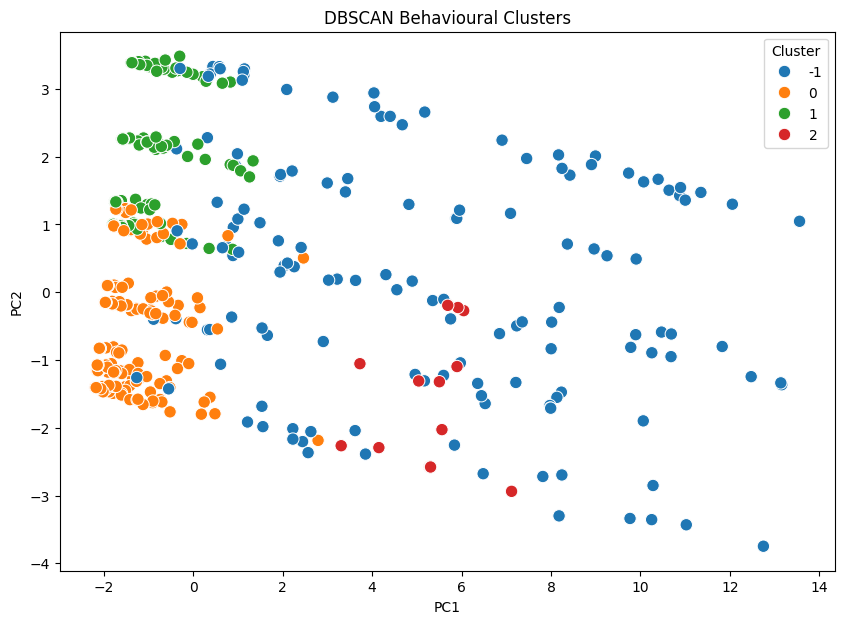

In [45]:
# PCA Cluster Visualization
#we chose dbscan bcs it has more shiloette score
cluster_plot = pd.DataFrame()

cluster_plot["PC1"] = pca_features[:,0]
cluster_plot["PC2"] = pca_features[:,1]
cluster_plot["Cluster"] = df["DBSCAN_Cluster"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("DBSCAN Behavioural Clusters")

plt.show()

In [46]:
cluster_profile = df.groupby("DBSCAN_Cluster")[[
    "ASIQ_Total_Score",
    "Social_Isolation_Score",
    "Relationship_Distress_Index",
    "Protective_Factor_Score",
    "Crisis_Risk_Score"
]].mean().round(2)

print("\nCluster Profiles")

print(cluster_profile)


Cluster Profiles
                ASIQ_Total_Score  Social_Isolation_Score  \
DBSCAN_Cluster                                             
-1                         63.32                    3.05   
 0                          2.38                    1.31   
 1                          4.57                    3.75   
 2                         73.29                    1.35   

                Relationship_Distress_Index  Protective_Factor_Score  \
DBSCAN_Cluster                                                         
-1                                     1.99                     2.17   
 0                                     2.11                     2.15   
 1                                     2.23                     2.01   
 2                                     1.82                     2.53   

                Crisis_Risk_Score  
DBSCAN_Cluster                     
-1                          66.18  
 0                           3.65  
 1                           8.55  
 2      

according to the observations we can conclude that
0 - low risk
1 - lil bit socially isolated
2 - high psychological distress
-1 - noise

In [47]:
cluster_summary = cluster_profile.copy()

cluster_summary["Suggested_Label"] = ""

for cluster in cluster_summary.index:

    row = cluster_summary.loc[cluster]

    if row["Crisis_Risk_Score"] == cluster_profile["Crisis_Risk_Score"].max():

        cluster_summary.loc[cluster,"Suggested_Label"] = "High Risk / Emotionally Distressed"

    elif row["Social_Isolation_Score"] == cluster_profile["Social_Isolation_Score"].max():

        cluster_summary.loc[cluster,"Suggested_Label"] = "Socially Isolated"

    elif row["Protective_Factor_Score"] == cluster_profile["Protective_Factor_Score"].max():

        cluster_summary.loc[cluster,"Suggested_Label"] = "Well Supported"

    else:

        cluster_summary.loc[cluster,"Suggested_Label"] = "Moderate Risk"

print(cluster_summary)

                ASIQ_Total_Score  Social_Isolation_Score  \
DBSCAN_Cluster                                             
-1                         63.32                    3.05   
 0                          2.38                    1.31   
 1                          4.57                    3.75   
 2                         73.29                    1.35   

                Relationship_Distress_Index  Protective_Factor_Score  \
DBSCAN_Cluster                                                         
-1                                     1.99                     2.17   
 0                                     2.11                     2.15   
 1                                     2.23                     2.01   
 2                                     1.82                     2.53   

                Crisis_Risk_Score                     Suggested_Label  
DBSCAN_Cluster                                                         
-1                          66.18                       Modera